# Credit Explainer — Phase 1 코어 데모

기존 실습과제 모형(**EasyEnsemble 20×HGB**, 홀드아웃 AUC 0.9247)을 그대로 코어로 사용하고,
그 위에 **XAI 설명 계층(SHAP Local·Counterfactual)** 과 **공정성 감사 계층**을 얹는 '신뢰 계층' 데모.

```
[평가 요청]
     ↓
[① 판단형 AI]  EasyEnsemble 20×HGB + Platt 보정  → PD 산출
[② XAI]        SHAP Local (개인별 Top 5 요인) · Counterfactual (개선 시뮬레이션)
[③ 생성형 AI]   SHAP 결과 → 자연어 설명문 "번역"  (본 노트북 범위 외 — 별도 진행)
[④ 거버넌스]    공정성 감사 (Demographic Parity · Equal Opportunity)
```

- 데이터: AI Play DB (약 20만 명), 타깃 `향후12개월내연체여부`
- 파이프라인 코드: `src/pipeline.py` (실습과제 검증 코드 포팅 — 로직 변경 없음)
- 기준 수치: 홀드아웃 **AUC 0.9247 / KS 0.7355** — 본 노트북에서 ±0.005 이내 재현을 확인한다.

## 0. 환경 설정

한글 폰트(맑은고딕)와 차트 팔레트를 설정하고, `src/pipeline.py`에서 파이프라인 모듈을 불러온다.

In [1]:
import warnings, sys, os
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
import shap, joblib

from pipeline import (seed, TARGET_COL, split_xy, add_features, EasyEnsembleHGB,
                      ks_stat, fit_platt_calibrator, calibrate)

# 한글 폰트: WSL이면 Windows 맑은고딕을 등록, Windows 네이티브면 이름만으로 사용 가능
for _fp in ['/mnt/c/Windows/Fonts/malgun.ttf', 'C:/Windows/Fonts/malgun.ttf']:
    if os.path.exists(_fp):
        fm.fontManager.addfont(_fp)
        break
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 차트 팔레트 (light 모드)
C = {'surface': '#fcfcfb', 'ink': '#0b0b0b', 'ink2': '#52514e', 'muted': '#898781',
     'grid': '#e1e0d9', 'axis': '#c3c2b7', 'blue': '#2a78d6', 'orange': '#eb6834',
     'red': '#d03b3b', 'good': '#0ca30c'}
plt.rcParams.update({'figure.facecolor': C['surface'], 'axes.facecolor': C['surface'],
                     'savefig.facecolor': C['surface'], 'text.color': C['ink'],
                     'axes.labelcolor': C['ink2'], 'xtick.color': C['ink2'], 'ytick.color': C['ink2']})

def style_ax(ax, grid_axis='y'):
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color(C['axis'])
    getattr(ax, grid_axis + 'axis').grid(True, color=C['grid'], lw=0.8)
    ax.set_axisbelow(True)

os.makedirs('../outputs', exist_ok=True)
print('환경 준비 완료')

환경 준비 완료


## 1. 데이터 준비

실습과제와 동일한 데이터·전처리를 사용한다. `split_xy`는 차주번호와 타깃 이외의
`향후*연체여부` 변수(누수 위험)를 제거한다.

In [2]:
df = pd.read_csv('../../data/AI_Play_DB.csv', encoding='cp949')
print(f'데이터: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'타깃({TARGET_COL}) 연체율: {df[TARGET_COL].mean():.4%}  (극도 불균형 → 언더샘플링 배깅 사용 이유)')
df.head(3)

데이터: 200,459행 × 43열
타깃(향후12개월내연체여부) 연체율: 0.2305%  (극도 불균형 → 언더샘플링 배깅 사용 이유)


,차주번호,신용대출잔액,신용대출건수,신용대출금리,장기카드대출잔액,장기카드대출건수,장기카드대출금리,단기카드대출잔액,단기카드대출건수,단기카드대출금리,...,보유보험수,월납입보험료,연금보험보유수,연금보험료,운전자보험보유수,운전자보험료,종신보험보유수,종신보험료,질병보험보유수,질병보험료
0,19,0,0,0.0,0,0,0.0,0,0,0.0,...,5,16,0,0,0,0,0,6,1,2
1,33,0,0,0.0,0,0,0.0,0,0,0.0,...,1,0,0,0,0,0,0,0,0,0
2,40,0,0,0.0,0,0,0.0,0,0,0.0,...,2,2,0,0,0,0,0,0,0,0


## 2. 기준 성능 재현 — ① 판단형 AI 계층

실습과제와 동일한 조건(seed 42, test_size 0.2 층화분할, 파생변수 16개,
EasyEnsemble 20×HGB)으로 학습하여 **AUC 0.9247 / KS 0.7355가 ±0.005 이내에서
재현되는지 확인**한다. 재현이 확인되어야 이후 설명·감사 결과가 실습과제 모형에 대한
설명임이 보장된다.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss

X, y = split_xy(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
Xf_tr, Xf_te = add_features(X_tr), add_features(X_te)

model = EasyEnsembleHGB(n_bags=20, ratio=1).fit(Xf_tr, y_tr)
p_raw = model.predict_proba1(Xf_te)

auc, ks = roc_auc_score(y_te, p_raw), ks_stat(y_te, p_raw)
print(f'홀드아웃 AUC = {auc:.4f}  (기준 0.9247, 차이 {auc - 0.9247:+.4f})')
print(f'홀드아웃 KS  = {ks:.4f}  (기준 0.7355, 차이 {ks - 0.7355:+.4f})')
assert abs(auc - 0.9247) <= 0.005 and abs(ks - 0.7355) <= 0.005, '기준 수치 재현 실패 — 멈추고 보고'
print('✔ 기준 수치 ±0.005 이내 재현 확인')

홀드아웃 AUC = 0.9230  (기준 0.9247, 차이 -0.0017)
홀드아웃 KS  = 0.7364  (기준 0.7355, 차이 +0.0009)
✔ 기준 수치 ±0.005 이내 재현 확인


## 3. Platt 보정 + 승인/거절 판정

언더샘플링(1:1) 학습 때문에 모형의 출력 확률은 실제 연체율(0.23%)보다 크게 부풀려져 있다.
**Platt 보정**(로짓 변환 후 로지스틱 회귀)으로 이를 현실 확률(PD)로 되돌린다.
보정기는 **학습셋 내부 5-fold OOF 예측**으로 학습하므로 홀드아웃 누수가 없다
(원 노트북 셀 16과 동일한 방식).

판정 임계값 **0.0443**은 실습과제에서 비용 기반(FN:FP = 10:1)으로 도출된 값을 그대로 사용한다.

In [4]:
calibrator, oof_tr = fit_platt_calibrator(Xf_tr, y_tr, n_splits=5)
pd_te = calibrate(calibrator, p_raw)

print(f'Brier score — 보정 전: {brier_score_loss(y_te, p_raw):.4f} / 보정 후: {brier_score_loss(y_te, pd_te):.5f}'
      f'  (참고: 항상 학습셋 연체율로 예측 시 {brier_score_loss(y_te, np.full(len(y_te), y_tr.mean())):.5f})')

  OOF fold 1/5 완료


  OOF fold 2/5 완료


  OOF fold 3/5 완료


  OOF fold 4/5 완료


  OOF fold 5/5 완료


Brier score — 보정 전: 0.1123 / 보정 후: 0.00224  (참고: 항상 학습셋 연체율로 예측 시 0.00229)


In [5]:
THRESHOLD = 0.0443  # 실습과제 비용 기반 임계값 (FN:FP = 10:1)

def decide(pd_arr, threshold=THRESHOLD):
    """보정 PD → 승인/거절 판정 ('거절' = PD가 임계값 이상)"""
    return np.where(np.asarray(pd_arr) >= threshold, '거절', '승인')

decision_te = decide(pd_te)
reject = decision_te == '거절'
y_arr = y_te.to_numpy()

tp = int((reject & (y_arr == 1)).sum()); fp = int((reject & (y_arr == 0)).sum())
fn = int((~reject & (y_arr == 1)).sum()); tn = int((~reject & (y_arr == 0)).sum())
print(f'홀드아웃 거절률: {reject.mean():.2%}  ({reject.sum():,}명 / {len(reject):,}명)')
print(f'TP={tp}  FP={fp:,}  FN={fn}  TN={tn:,}')
print(f'실제 연체자 {int(y_arr.sum())}명 중 {tp}명 사전 차단 (적발률 {tp / y_arr.sum():.1%})')

홀드아웃 거절률: 0.80%  (322명 / 40,092명)
TP=29  FP=293  FN=63  TN=39,707
실제 연체자 92명 중 29명 사전 차단 (적발률 31.5%)


## 4. SHAP Local 분석 — ② XAI 계층

홀드아웃에서 대표 사례 3건을 뽑아 개인별 상위 5개 기여 변수를 산출한다.

- **사례 1 — 고위험 거절**: 보정 PD가 가장 높은 고객
- **사례 2 — 저위험 승인**: 보정 PD가 가장 낮은 고객
- **사례 3 — 경계**: PD가 임계값(0.0443) 바로 위인 고객 (5절 Counterfactual 대상)

> **방법상 한계 (명시)** — 본 모형은 20개 HGB 파이프라인의 **배깅 앙상블**이라
> 앙상블 전체의 SHAP 값을 엄밀하게 구하려면 20개 모형 각각의 SHAP을 평균해야 한다.
> 여기서는 계산·해석 단순화를 위해 **대표 파이프라인 1개(첫 번째 백)** 로 SHAP을 계산한다.
> 따라서 SHAP 값의 단위는 그 대표 모형의 **log-odds**이고(언더샘플 1:1 학습 기준),
> 앙상블 평균 PD와 수치가 정확히 일치하지는 않는다. 기여 방향과 순위를 읽는 용도로
> 해석하며, 실서비스라면 20개 모형 SHAP 평균으로 대체해야 한다.

In [6]:
# 대표 사례 3건 선정
pos_reject = int(np.argmax(pd_te))    # 사례 1: 고위험 거절
pos_approve = int(np.argmin(pd_te))   # 사례 2: 저위험 승인
cands = np.where(pd_te >= THRESHOLD)[0]
cands = cands[np.argsort(pd_te[cands] - THRESHOLD)]
# 사례 3(경계)은 Counterfactual에서 다룰 행동 가능 변수(단기카드·2금융권 잔액)가 있는 고객 우선
pos_border = int(next((c for c in cands
                       if X_te.iloc[c]['단기카드대출잔액'] > 0 and X_te.iloc[c]['2금융권대출잔액'] > 0),
                      cands[0]))

cases = [('고위험 거절', pos_reject), ('저위험 승인', pos_approve), ('경계(임계값 부근)', pos_border)]
for name, p in cases:
    print(f'{name:11s} — 홀드아웃 위치 {p:5d} · PD {pd_te[p]:.4f} · 판정 {decision_te[p]} · 실제 연체 {y_arr[p]}')

고위험 거절      — 홀드아웃 위치 29618 · PD 0.5012 · 판정 거절 · 실제 연체 0
저위험 승인      — 홀드아웃 위치    78 · PD 0.0000 · 판정 승인 · 실제 연체 0
경계(임계값 부근)  — 홀드아웃 위치 37963 · PD 0.0449 · 판정 거절 · 실제 연체 0


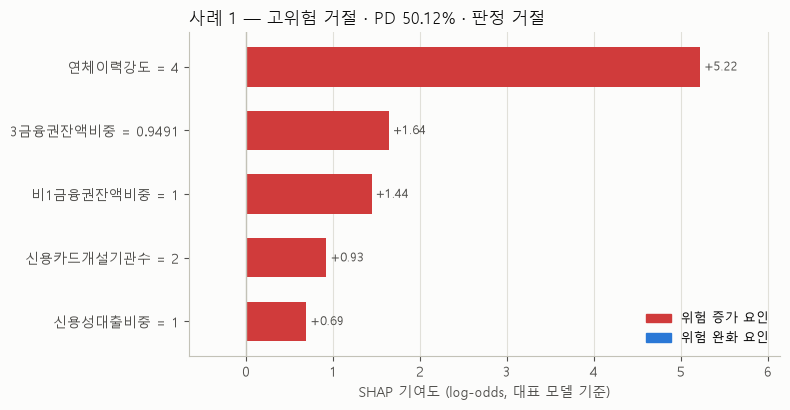

,변수,고객값,SHAP(log-odds)
0,연체이력강도,4.0000,5.2213
1,3금융권잔액비중,0.9491,1.6413
2,비1금융권잔액비중,1.0000,1.4438
3,신용카드개설기관수,2.0000,0.9257
4,신용성대출비중,1.0000,0.6936


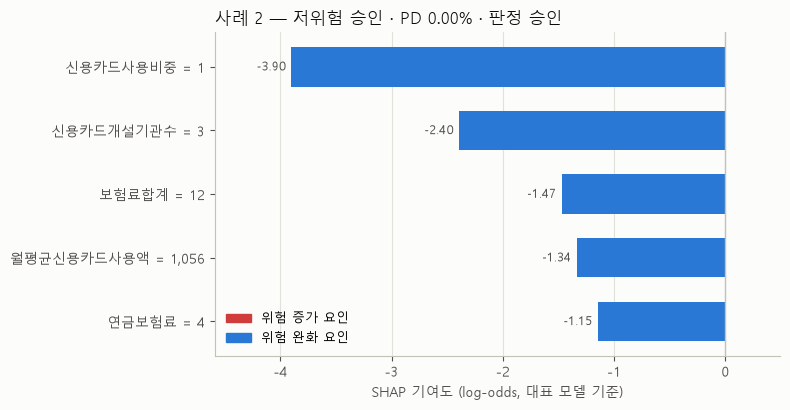

,변수,고객값,SHAP(log-odds)
0,신용카드사용비중,1.0000,-3.9039
1,신용카드개설기관수,3.0000,-2.3967
2,보험료합계,12.0000,-1.4726
3,월평균신용카드사용액,1056.2667,-1.3375
4,연금보험료,4.0000,-1.1459


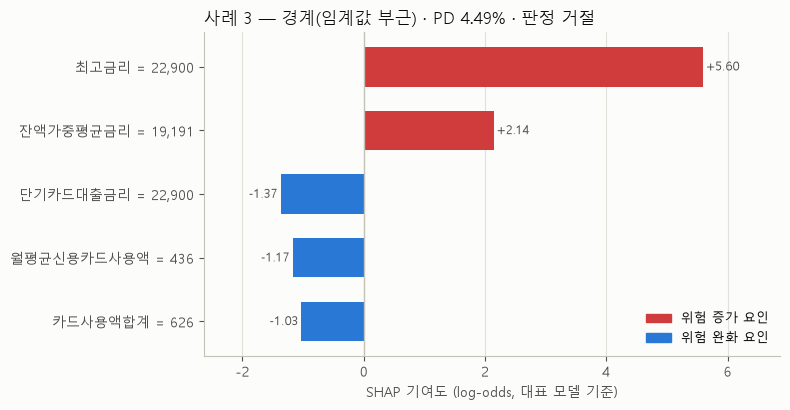

,변수,고객값,SHAP(log-odds)
0,최고금리,22900.0000,5.5959
1,잔액가중평균금리,19190.8367,2.1428
2,단기카드대출금리,22900.0000,-1.3710
3,월평균신용카드사용액,436.0000,-1.1720
4,카드사용액합계,626.0000,-1.0308


저장: outputs/shap_case_1~3.png, outputs/shap_top5_cases.csv


In [7]:
rep = model.pipes_[0]  # 대표 파이프라인 (한계는 위 마크다운 참조)
pre, clf = rep.named_steps['pre'], rep.named_steps['clf']

# 전처리 출력 순서(log→num→bin)에 맞춰 변수명 복원 — make_preprocess와 동일한 분류 규칙
bin_cols = [c for c in Xf_te.columns if '여부' in c]
num_cols = [c for c in Xf_te.columns if c not in bin_cols]
log_cols = [c for c in num_cols if any(t in c for t in ['잔액', '사용액', '보험료'])]
lin_cols = [c for c in num_cols if c not in log_cols]
feat_names = log_cols + lin_cols + bin_cols

positions = [p for _, p in cases]
sv = shap.TreeExplainer(clf)(pre.transform(Xf_te.iloc[positions]))

shap_top5 = {}
for i, (name, p) in enumerate(cases, start=1):
    vals = sv.values[i - 1]
    top = np.argsort(np.abs(vals))[::-1][:5]
    rows = pd.DataFrame({'변수': [feat_names[j] for j in top],
                         '고객값': [float(Xf_te.iloc[p][feat_names[j]]) for j in top],
                         'SHAP(log-odds)': vals[top]})
    shap_top5[i] = rows

    plot = rows.iloc[::-1]
    colors = [C['red'] if v > 0 else C['blue'] for v in plot['SHAP(log-odds)']]
    fmt_val = lambda v: f'{v:,.0f}' if abs(v) >= 100 else f'{v:.4g}'
    labels = [f'{r.변수} = {fmt_val(r.고객값)}' for r in plot.itertuples()]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.barh(labels, plot['SHAP(log-odds)'], color=colors, height=0.62)
    ax.axvline(0, color=C['axis'], lw=1)
    style_ax(ax, grid_axis='x')
    for k, v in enumerate(plot['SHAP(log-odds)']):
        ax.text(v + (0.05 if v >= 0 else -0.05), k, f'{v:+.2f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=9, color=C['ink2'])
    ax.set_xlabel('SHAP 기여도 (log-odds, 대표 모델 기준)')
    ax.set_title(f'사례 {i} — {name} · PD {pd_te[p]:.2%} · 판정 {decision_te[p]}',
                 loc='left', fontsize=12, color=C['ink'])
    ax.legend(handles=[Patch(color=C['red'], label='위험 증가 요인'),
                       Patch(color=C['blue'], label='위험 완화 요인')],
              frameon=False, fontsize=9,
              loc='lower right' if plot['SHAP(log-odds)'].mean() >= 0 else 'lower left')
    xmin, xmax = ax.get_xlim(); pad = (xmax - xmin) * 0.12
    ax.set_xlim(xmin - pad, xmax + pad)
    plt.tight_layout()
    fig.savefig(f'../outputs/shap_case_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(rows.round(4))

# ③ 생성형 AI 계층(LLM 번역)의 입력으로 쓸 수 있게 사례별 Top5를 저장
pd.concat(shap_top5, names=['사례']).to_csv('../outputs/shap_top5_cases.csv', encoding='utf-8-sig')
print('저장: outputs/shap_case_1~3.png, outputs/shap_top5_cases.csv')

## 5. Counterfactual 시뮬레이션 (수동 구현)

경계 사례(사례 3)에 대해 **"어떤 변수를 얼마나 바꾸면 승인으로 바뀌는가"** 를 격자 탐색한다.
고객이 실제로 행동할 수 있는 변수 3개만 움직인다:

| 변수 | 탐색 격자 | 행동 의미 |
|---|---|---|
| 단기카드대출잔액 | 0 / 25 / 50 / 75 / 100% 감소 | 카드론·현금서비스 상환 |
| 2금융권대출잔액 | 0 / 25 / 50 / 75 / 100% 감소 | 저축은행 등 2금융권 대출 상환 |
| 단기카드대출건수 | 0 / 1 / 2건 감소 | 단기카드대출 계좌 정리 |

변수를 바꾼 뒤 **파생변수를 다시 계산**하고 앙상블 20개 전체로 재예측하므로,
파생변수(총대출잔액, 비중류 등)에 미치는 연쇄 효과가 자동 반영된다.

> **해석상 주의** — 이는 "모형 관점"의 시뮬레이션이다. 세 변수를 서로 독립적으로 움직일 수
> 있다고 가정했고(실제로는 단기카드대출이 2금융권 잔액에 포함되는 등 상관 존재),
> 인과 효과가 아니라 모형 예측의 변화를 보여준다. '변화량 합계'는 잔액 감소율 합계에
> 건수 1건당 0.25를 더한 단순 비용 지표다.

In [8]:
CF_VARS = ['단기카드대출잔액', '2금융권대출잔액', '단기카드대출건수']
row = X_te.iloc[[pos_border]]
print(f'경계 사례 — 현재 PD {pd_te[pos_border]:.4f} (임계값 {THRESHOLD}) · 판정 {decision_te[pos_border]}')
print(row[CF_VARS].T.rename(columns={row.index[0]: '현재 값'}))

balance_cuts = [0.0, 0.25, 0.5, 0.75, 1.0]
count_cuts = [0, 1, 2]
combos, mods = [], []
for r1 in balance_cuts:
    for r2 in balance_cuts:
        for dc in count_cuts:
            m = row.copy()
            m['단기카드대출잔액'] = m['단기카드대출잔액'] * (1 - r1)
            m['2금융권대출잔액'] = m['2금융권대출잔액'] * (1 - r2)
            m['단기카드대출건수'] = max(0, int(row['단기카드대출건수'].iloc[0]) - dc)
            combos.append((r1, r2, dc)); mods.append(m)

X_cf = pd.concat(mods, ignore_index=True)
pd_cf = calibrate(calibrator, model.predict_proba1(add_features(X_cf)))

cf = pd.DataFrame(combos, columns=['단기카드잔액 감소율', '2금융권잔액 감소율', '단기카드건수 감소'])
cf['예상 PD'] = pd_cf.round(4)
cf['판정'] = decide(pd_cf)
cf['변화량 합계'] = cf['단기카드잔액 감소율'] + cf['2금융권잔액 감소율'] + cf['단기카드건수 감소'] * 0.25
passed = cf[cf['판정'] == '승인'].sort_values(['변화량 합계', '예상 PD']).reset_index(drop=True)

print(f'\n승인 전환 조합: {len(passed)}개 / 전체 {len(cf)}개')
if len(passed):
    best = passed.iloc[0]
    print('최소 변화 조합:')
    print(f"  단기카드대출잔액 {best['단기카드잔액 감소율']:.0%} 상환"
          f" + 2금융권대출잔액 {best['2금융권잔액 감소율']:.0%} 상환"
          f" + 단기카드대출건수 {int(best['단기카드건수 감소'])}건 감소"
          f" → PD {best['예상 PD']:.4f} (임계값 {THRESHOLD} 미만, 승인 전환)")
    display(passed.head(10))
    # 02 노트북(설명문 생성)에서 재사용할 수 있게 결과 저장
    import json
    cf_out = {'pos_border': int(pos_border),
              'current_pd': float(pd_te[pos_border]), 'threshold': float(THRESHOLD),
              'current_values': {v: float(row[v].iloc[0]) for v in CF_VARS},
              'best': {k: float(best[k]) for k in ['단기카드잔액 감소율', '2금융권잔액 감소율', '단기카드건수 감소', '예상 PD']}}
    with open('../outputs/counterfactual_result.json', 'w', encoding='utf-8') as f:
        json.dump(cf_out, f, ensure_ascii=False, indent=2)
    print('저장: outputs/counterfactual_result.json')
else:
    print('격자 내 조합으로는 임계값 아래로 내려가지 않음 — 탐색 범위 확대 필요 (멈추고 보고)')

경계 사례 — 현재 PD 0.0449 (임계값 0.0443) · 판정 거절
          현재 값
단기카드대출잔액   120
2금융권대출잔액  4900
단기카드대출건수     1



승인 전환 조합: 69개 / 전체 75개
최소 변화 조합:
  단기카드대출잔액 25% 상환 + 2금융권대출잔액 0% 상환 + 단기카드대출건수 0건 감소 → PD 0.0206 (임계값 0.0443 미만, 승인 전환)


,단기카드잔액 감소율,2금융권잔액 감소율,단기카드건수 감소,예상 PD,판정,변화량 합계
0,0.25,0.00,0,0.0206,승인,0.25
1,0.00,0.00,1,0.0399,승인,0.25
2,0.25,0.00,1,0.0186,승인,0.50
3,0.50,0.00,0,0.0206,승인,0.50
4,0.25,0.25,0,0.0211,승인,0.50
5,0.00,0.00,2,0.0399,승인,0.50
6,0.00,0.25,1,0.0407,승인,0.50
7,0.25,0.00,2,0.0186,승인,0.75
8,0.50,0.00,1,0.0186,승인,0.75
9,0.25,0.25,1,0.0190,승인,0.75


저장: outputs/counterfactual_result.json


## 6. 공정성 감사 — ④ 거버넌스 계층

**왜 프록시 그룹인가** — 신용평가 기초데이터에는 성별·연령 같은 인구통계 변수가 없다
(신용정보법상 신용평가에 법적으로 배제되는 정보). 인구통계 변수가 없다고 감사가 불가능한 것은
아니다 — 오히려 **대리변수(Proxy)를 통한 우회 차별**이 핵심 위험이므로(부록 7절의 사면 실험이
그 실증), 취약계층과 상관이 높은 **프록시 그룹으로 세분화 평가**를 수행한다.

- **그룹 A**: `3금융권대출잔액 > 0` — 대부업 등 3금융권 이용자 (취약차주 프록시)
- **그룹 B**: 나머지

산출 지표 (거절 = 양성 예측 기준):

| 공정성 기준 | 지표 | 질문 |
|---|---|---|
| Demographic Parity | 거절률 격차 | 두 그룹의 거절 비율이 비슷한가? |
| Equal Opportunity | FNR 격차 | 정상 상환할 고객이 승인받을 기회가 같은가?* |
| Equalized Odds (보조) | FPR 격차 | 정상 고객이 억울하게 거절될 확률이 같은가? |

*FNR(연체인데 승인)·FPR(정상인데 거절)은 실제 라벨 조건부 오류율로, 두 격차가 모두 작으면
Equalized Odds에 가깝다.

> **한계** — 프록시 그룹은 실제 보호 속성(연령·성별 등)과 다르며, 3금융권 이용 여부 자체가
> 신용위험과 상관이 있어 격차의 일부는 실제 위험 차이를 반영한다. 격차가 크다는 것 자체가
> 차별의 증거는 아니고, **추가 조사가 필요한 신호**로 읽어야 한다.

In [9]:
grpA = (X_te['3금융권대출잔액'] > 0).to_numpy()

rows = []
for gname, mask in [('그룹A (3금융권 이용)', grpA), ('그룹B (미이용)', ~grpA)]:
    y_g, rej_g = y_arr[mask], reject[mask]
    n0, n1 = int((y_g == 0).sum()), int((y_g == 1).sum())
    rows.append({'그룹': gname, 'N': int(mask.sum()), '실제 연체자수': n1,
                 '실제 연체율': y_g.mean(), '거절률': rej_g.mean(),
                 'FPR(정상인데 거절)': float((rej_g & (y_g == 0)).sum() / n0),
                 'FNR(연체인데 승인)': float((~rej_g & (y_g == 1)).sum() / n1) if n1 else np.nan})
fair = pd.DataFrame(rows).set_index('그룹')
display(fair.round(4))

gaps = pd.DataFrame([
    {'공정성 기준': 'Demographic Parity', '지표': '거절률 격차',
     '격차': abs(fair['거절률'].iloc[0] - fair['거절률'].iloc[1])},
    {'공정성 기준': 'Equal Opportunity', '지표': 'FNR 격차',
     '격차': abs(fair['FNR(연체인데 승인)'].iloc[0] - fair['FNR(연체인데 승인)'].iloc[1])},
    {'공정성 기준': 'Equalized Odds (보조)', '지표': 'FPR 격차',
     '격차': abs(fair['FPR(정상인데 거절)'].iloc[0] - fair['FPR(정상인데 거절)'].iloc[1])},
])
display(gaps.round(4))

,N,실제 연체자수,실제 연체율,거절률,FPR(정상인데 거절),FNR(연체인데 승인)
그룹,,,,,,
그룹A (3금융권 이용),376,20,0.0532,0.3191,0.3174,0.6500
그룹B (미이용),39716,72,0.0018,0.0051,0.0045,0.6944


,공정성 기준,지표,격차
0,Demographic Parity,거절률 격차,0.3141
1,Equal Opportunity,FNR 격차,0.0444
2,Equalized Odds (보조),FPR 격차,0.3129


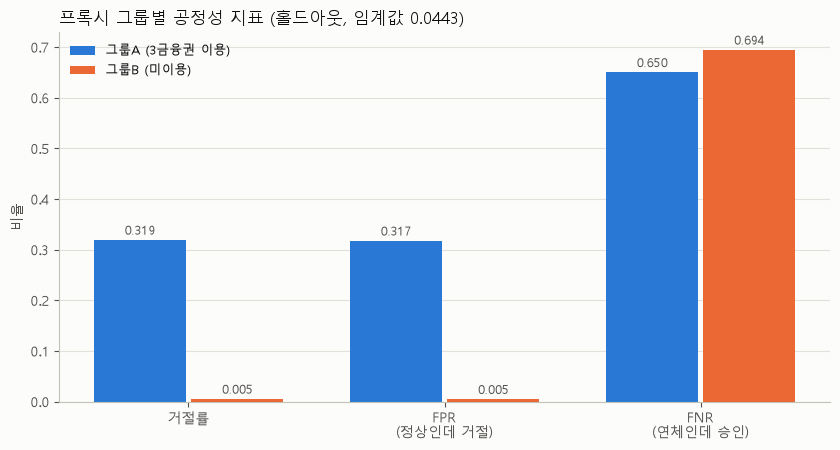

In [10]:
metrics = ['거절률', 'FPR(정상인데 거절)', 'FNR(연체인데 승인)']
x = np.arange(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.6))
b1 = ax.bar(x - w / 2, fair[metrics].iloc[0], w * 0.94, color=C['blue'], label=fair.index[0])
b2 = ax.bar(x + w / 2, fair[metrics].iloc[1], w * 0.94, color=C['orange'], label=fair.index[1])
for bars in (b1, b2):
    ax.bar_label(bars, fmt='%.3f', fontsize=9, color=C['ink2'], padding=2)
style_ax(ax)
ax.set_xticks(x, ['거절률', 'FPR\n(정상인데 거절)', 'FNR\n(연체인데 승인)'])
ax.set_ylabel('비율')
ax.set_title('프록시 그룹별 공정성 지표 (홀드아웃, 임계값 0.0443)', loc='left', fontsize=12, color=C['ink'])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig.savefig('../outputs/fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 부록 — 신용사면 시뮬레이션 (완료된 실험 정리)

연체기록 4개 변수를 삭제(사면)해도 모형 성능이 거의 떨어지지 않는다는 자체 실험 결과
(`experiments/sim_amnesty.py`). **"변수를 지워도 모형은 다른 변수로 우회 학습한다"** 는
대리변수 문제의 직접 실증이며, 6절 공정성 감사(사후 세분화 평가)가 필요한 이유다.

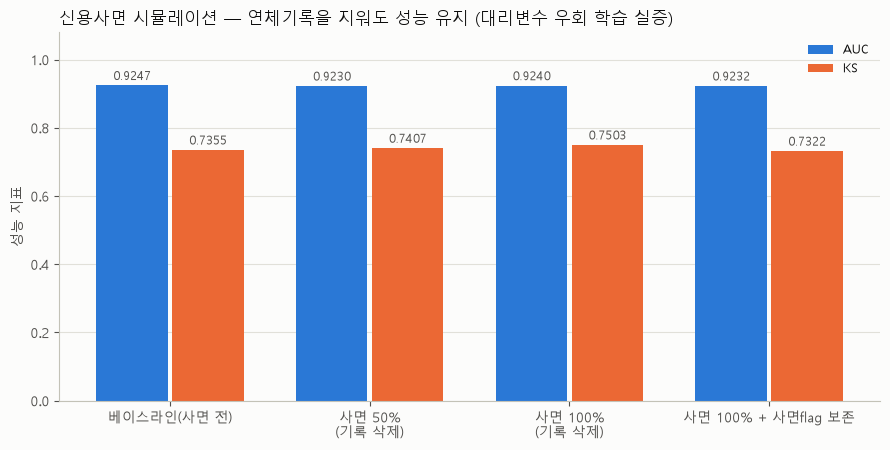

,시나리오,AUC,KS
0,베이스라인(사면 전),0.9247,0.7355
1,사면 50% (기록 삭제),0.9230,0.7407
2,사면 100% (기록 삭제),0.9240,0.7503
3,사면 100% + 사면flag 보존,0.9232,0.7322


In [11]:
amn = pd.read_csv('../experiments/amnesty_results.csv')
x = np.arange(len(amn)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.6))
b1 = ax.bar(x - w / 2, amn['AUC'], w * 0.94, color=C['blue'], label='AUC')
b2 = ax.bar(x + w / 2, amn['KS'], w * 0.94, color=C['orange'], label='KS')
for bars in (b1, b2):
    ax.bar_label(bars, fmt='%.4f', fontsize=9, color=C['ink2'], padding=2)
style_ax(ax)
ax.set_xticks(x, [s.replace(' (', '\n(') for s in amn['시나리오']])
ax.set_ylim(0, 1.08)
ax.set_ylabel('성능 지표')
ax.set_title('신용사면 시뮬레이션 — 연체기록을 지워도 성능 유지 (대리변수 우회 학습 실증)',
             loc='left', fontsize=12, color=C['ink'])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
fig.savefig('../outputs/amnesty_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
amn

## 8. 아티팩트 저장 및 결론

Phase 2(발표자료)와 ③ 생성형 AI 계층(LLM 설명문 번역)에서 재사용할 수 있도록
보정기·임계값·사례 정보를 저장한다. 앙상블 본체는 11초면 재학습되므로 저장하지 않는다
(OOF 보정만 약 1분 소요 → 보정기는 저장).

In [12]:
joblib.dump({'calibrator': calibrator, 'threshold': THRESHOLD,
             'metrics': {'auc': float(auc), 'ks': float(ks)},
             'cases': {name: int(p) for name, p in cases}},
            '../outputs/calibration_artifacts.joblib')
print('저장 완료: outputs/calibration_artifacts.joblib')
print(f'\n=== Phase 1 코어 요약 ===')
print(f'기준 재현: AUC {auc:.4f} / KS {ks:.4f} (기준 0.9247 / 0.7355, ±0.005 이내)')
print(f'거절률 {reject.mean():.2%} @ 임계값 {THRESHOLD}, 연체자 적발률 {tp / y_arr.sum():.1%}')
for i, (name, p) in enumerate(cases, 1):
    top1 = shap_top5[i].iloc[0]
    print(f'사례 {i} ({name}): PD {pd_te[p]:.4f}, 최대 기여 변수 {top1.변수} ({top1["SHAP(log-odds)"]:+.2f})')

저장 완료: outputs/calibration_artifacts.joblib

=== Phase 1 코어 요약 ===
기준 재현: AUC 0.9230 / KS 0.7364 (기준 0.9247 / 0.7355, ±0.005 이내)
거절률 0.80% @ 임계값 0.0443, 연체자 적발률 31.5%
사례 1 (고위험 거절): PD 0.5012, 최대 기여 변수 연체이력강도 (+5.22)
사례 2 (저위험 승인): PD 0.0000, 최대 기여 변수 신용카드사용비중 (-3.90)
사례 3 (경계(임계값 부근)): PD 0.0449, 최대 기여 변수 최고금리 (+5.60)


### 한계 및 다음 단계

- **SHAP 대표 모형 근사** — 배깅 20개 중 1개로 계산 (4절 명시). 실서비스는 전체 평균 필요.
- **Counterfactual은 인과가 아님** — 모형 관점의 시뮬레이션 (5절 명시).
- **프록시 그룹의 한계** — 격차는 차별의 증거가 아니라 조사 신호 (6절 명시).
- **다음 단계** — ③ 생성형 AI 계층: `outputs/shap_top5_cases.csv`를 입력으로
  템플릿 제약 프롬프트 기반 자연어 설명문 생성 (별도 진행, 외부 API 결정 후).
  이후 Phase 2 발표자료 조립.